Tên: Nguyễn Trọng Phúc, MSSV: 2510194

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
#Phần 1: Thống kê mô tả & đặc trưng
#1.
df = sns.load_dataset("iris")

#1.1. Hiển thị 5 dòng đầu
print("Hiển thị 5 dòng đầu:")
print(df.head())

#1.2. Số dòng, cột
print("\nSố dòng và cột:")
print(df.shape)

#1.3. Kiểu dữ liệu của từng cột
print("\nKiểu dữ liệu của từng cột: ")
print(df.dtypes)


Hiển thị 5 dòng đầu:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng và cột:
(150, 5)

Kiểu dữ liệu của từng cột: 
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


1.1
- Thư viện seaborn dùng để tải 1 mẫu dữ liệu (ở đây là iris) gồm kích thước của 150 bông hoa diên vĩ thuộc 3 loài khác nhau, bảng gồm 5 cột (5 thuộc tính) và 150 dòng.
- Thư viện pandas dùng để tính toán thống kê trên mẫu số liệu
- Các comments đã có chú thích cụ thể ở từng syntax, vì ở đây không có ý nghĩa sâu xa nên không giải thích gì thêm

In [4]:
#2. 
def q1(x):
    return x.quantile(0.25)
def q3(x):
    return x.quantile(0.75)
def iqr(x):
    return q3(x) - q1(x)
def custom_mode(x):
    return x.mode().tolist()

numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
custom_mode.__name__ = 'mode'

statistic_board = df[numeric_cols].agg(['mean', 'median', custom_mode, 'var', 'std', 'min', 'max', q1, q3, iqr])

print(statistic_board)


       sepal_length sepal_width petal_length petal_width
mean       5.843333    3.057333        3.758    1.199333
median          5.8         3.0         4.35         1.3
mode          [5.0]       [3.0]   [1.4, 1.5]       [0.2]
var        0.685694    0.189979     3.116278    0.581006
std        0.828066    0.435866     1.765298    0.762238
min             4.3         2.0          1.0         0.1
max             7.9         4.4          6.9         2.5
q1              5.1         2.8          1.6         0.3
q3              6.4         3.3          5.1         1.8
iqr             1.3         0.5          3.5         1.5


1.2. Để có thể tính toán và biểu diễn dễ nhìn cho từng biến (trừ species), ta sẽ sử dụng lệnh 'agg' trong pandas để viết toàn bộ các số liệu thống kê. Nhưng pandas chỉ hỗ trợ sẵn các phép toán như 'mean', 'median',..., không có các phép tính 'q1', 'q3' hay 'iqr', còn với 'mode', tuy pandas có thể hiểu được lệnh này nhưng 'mode' trả về 1 chuỗi các số, trong khi bảng agg lại hiện các con số đơn lẻ nên ta cần định nghĩa lại 4 phép tính trên. 


In [5]:
board_for_each_species = df.groupby('species')[numeric_cols].agg(['mean', 'std'])

print(board_for_each_species)

           sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650  


1.3.
- Tương tự 1.2. nhưng ta sẽ thêm 'groupby' vào để phân loại ra 3 giống của hoa Iris, còn lại agg là để tính và đưa vào chung 1 bảng cho đẹp.
- Có thể thấy giống 'setosa' có sự khác biệt lớn với 2 loài còn lại, trong khi 2 loài còn lại là 'versicolor' và 'virginica' có kích thước khá tương đồng và phân phối bị chồng lấn lên nhau. Do đó, cụm dữ liệu của 'setosa' sẽ hoàn toàn tách biệt, giúp các mô hình phân lớp dễ dàng nhận diện chính xác loài này hơn so với việc phân biệt giữa 'versicolor' và 'virginica'.

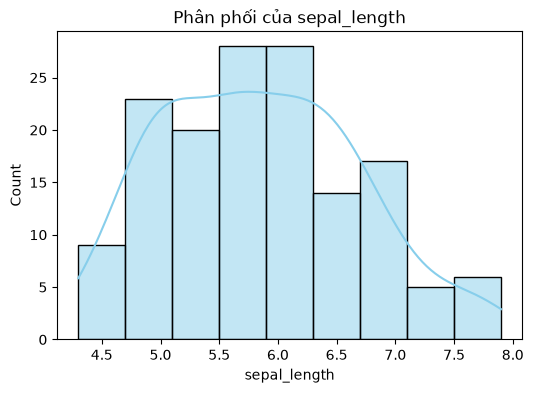

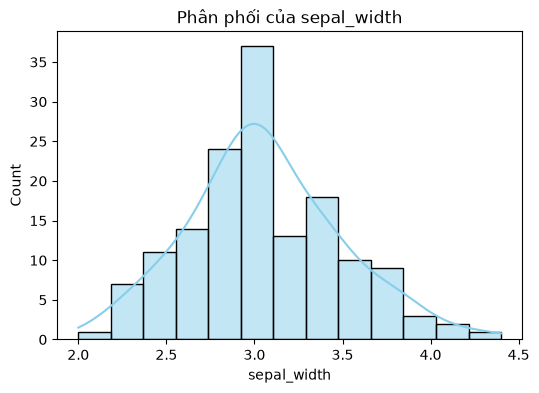

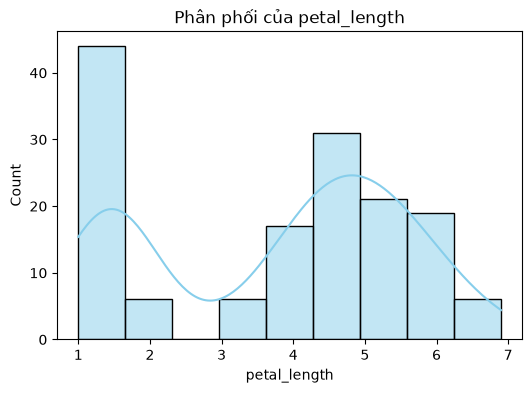

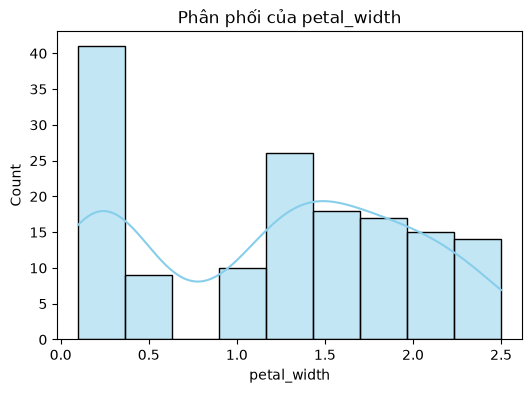

In [6]:
#Phần 2: Phân phối xác suất
#2.1. Vẽ histogram và KDE cho từng biến số
for col in numeric_cols:
    plt.figure(figsize=(6, 4)) 
    
    sns.histplot(data=df, x=col, kde=True, color = 'skyblue')
    
    plt.title(f'Phân phối của {col}')
    plt.show()

2.1.
Dựa trên đồ thị, biến 'sepal_length' có phân phối lệch phải, biến 'sepal_width' có phân phối gần chuẩn, 2 biến 'petal_length' và 'petal_width' có phân phối đa đỉnh

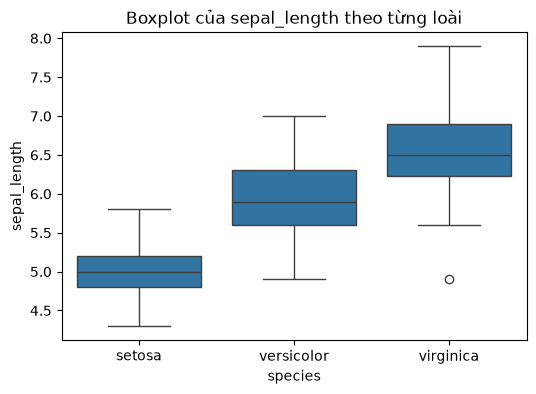

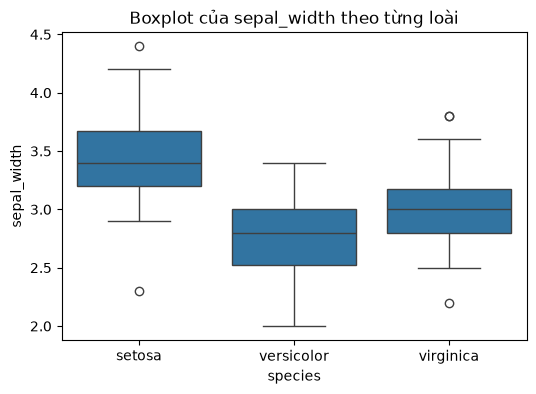

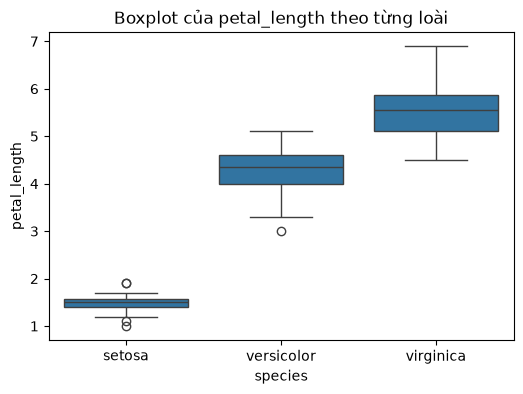

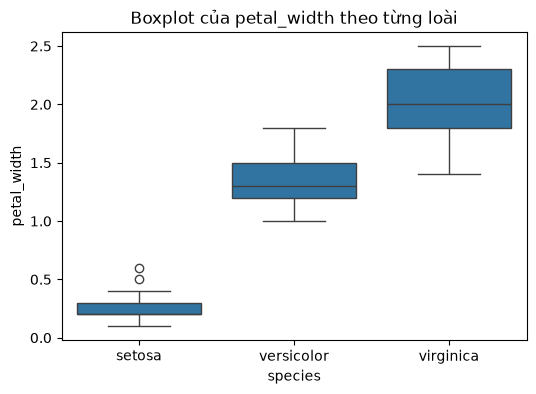

In [7]:
#2.2. Vẽ boxplot theo từng biến
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(data=df, x='species', y=col)
    
    plt.title(f'Boxplot của {col} theo từng loài')
    plt.show()

2.2. Trong boxplot trên, có thể thấy sự khác biệt giữa giống 'setosa' và 2 giống còn lại, boxplot của 'setosa'nằm tách biệt hoàn toàn ở 1 miền giá trị riêng ở 2 biến 'petal_length' và 'petal_width'. Trong khi đó, 2 giống 'versicolor' và 'virginica' có boxplot gần giống nhau, có phạm vi hay mức phân tán cùng chung 1 đoạn nhất định trong thống kê tất cả các biến, điều này cho thấy việc khó phân biệt giữa 2 loài 'versicolor' và 'virginica' trong khi cực kỳ dễ phân biệt giống 'setosa' theo biến 'petal_width' và 'petal_length'.

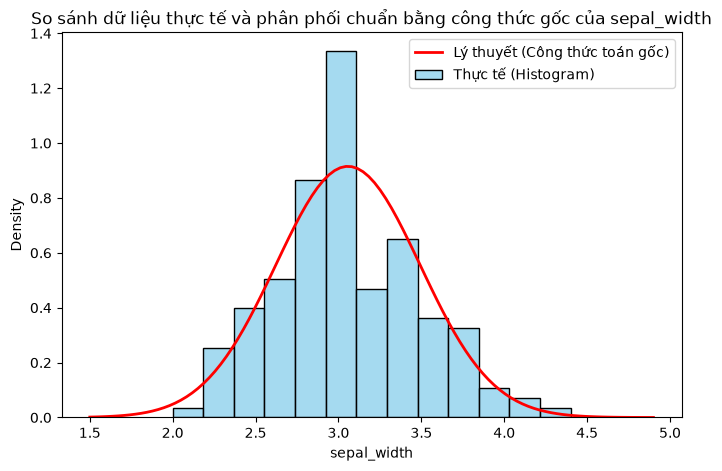

In [8]:
#2.3. Vẽ histogram và PDF Normal để so sánh
col = 'sepal_width'
thuc_te = df[col]
muy = thuc_te.mean()
sigma = thuc_te.std()

xmin, xmax = thuc_te.min() - 0.5, thuc_te.max() + 0.5
x = np.linspace(xmin, xmax, 100)

he_so = 1 / (sigma * np.sqrt(2 * np.pi))
so_mu = -0.5 * ((x - muy) / sigma) ** 2
y_ly_thuyet = he_so * np.exp(so_mu)

plt.figure(figsize=(8, 5))

sns.histplot(thuc_te, stat='density', color='skyblue', label='Thực tế (Histogram)')

plt.plot(x, y_ly_thuyet, color='red', linewidth=2, label='Lý thuyết (Công thức toán gốc)')

plt.title(f'So sánh dữ liệu thực tế và phân phối chuẩn bằng công thức gốc của {col}')
plt.legend()
plt.show()

2.3. Dữ liệu thực tế có hình dáng quả chuông khá gần với đường phân phối chuẩn. Tuy vậy, có 1 số điểm khác biệt như độ lệch ở đỉnh, dữ liệu cho thấy mức độ tập trung dày đặc ở phần giá trị trung bình là 3.0, nên đỉnh của histogram cao hơn khá nhiều so với đường cong phân phối chuẩn. 

In [43]:
#Phần 3: Phân tích đa biến & tương quan
#3.1. Ma trận cov và corr giữa các biến

cov = df[numeric_cols].cov()
corr = df[numeric_cols].corr()

cov_matrix = cov.to_numpy()
corr_matrix = corr.to_numpy()

print("Ma trận Covariance:\n", cov_matrix)
print("Ma trận Correlation:\n", corr_matrix)

Ma trận Covariance:
 [[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]
Ma trận Correlation:
 [[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


3.1. Có thể thấy rằng:
- Cả 2 ma trận đều là ma trận đối xứng, các pivot trên ma trận cov chính là phương sai của chính biến đó, pivot của ma trận corr sẽ luôn = 1 vì biến đó sẽ tương quan hoàn hảo với chính nó.
- Ở ma trận cov, các giá trị dương cho biết 2 biến biến thiên cùng chiều, và giá trị âm cho thấy điều ngược lại. Tuy vậy, về cơ bản, ta không thể đánh giá được cường độ mạnh yếu của biến thiên này vì giá trị cov phụ thuộc vào đơn vị của dữ liệu. Nên để đánh giá, ta cần nhìn qua ma trận corr chỉ chứa các giá trị chạy từ -1 đến 1, có thể thấy giá trị xấp xỉ 0.963 cho thấy mức độ biến thiên của 2 biến này rất mạnh vì rất gần 1.

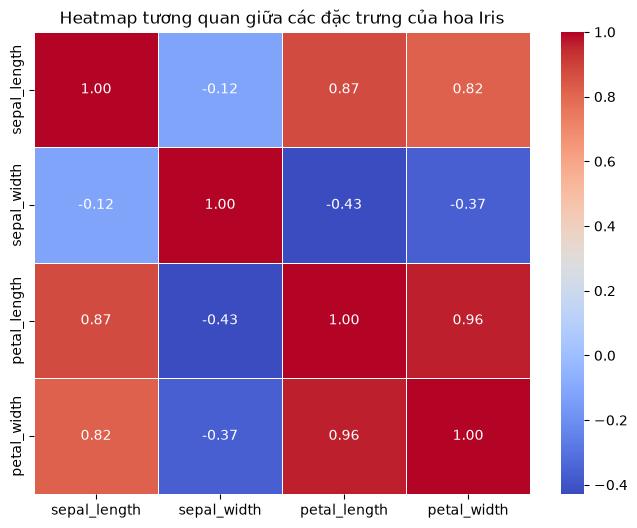

In [44]:
#3.2. Vẽ heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Heatmap tương quan giữa các đặc trưng của hoa Iris')
plt.show()

3.2.
- Dựa vào biểu đồ Heatmap, cặp biến có độ tương quan mạnh nhất là 'petal_length' và'petal_width' với hệ số tương quan đạt 0.96. Điều này thể hiện mối tương quan mạnh nhất giữa 2 biến. 
- Tuy vậy, hệ số tương quan của 2 biến này vượt ngưỡng 0.8, cho thấy dữ liệu đang bị thừa thông tin, theo đó đây cũng là dấu hiệu của hiện tượng đa cộng tuyến. Để rõ hơn, ta thử áp dụng công thức tính hệ số phóng đại phương sai (VIF) như sau:
VIF = 1/(1-R^2) = 1/(1-0.96^2) = 12.755 > 10, chứng tỏ xảy ra hiện tượng đa cộng tuyến nghiệm trọng


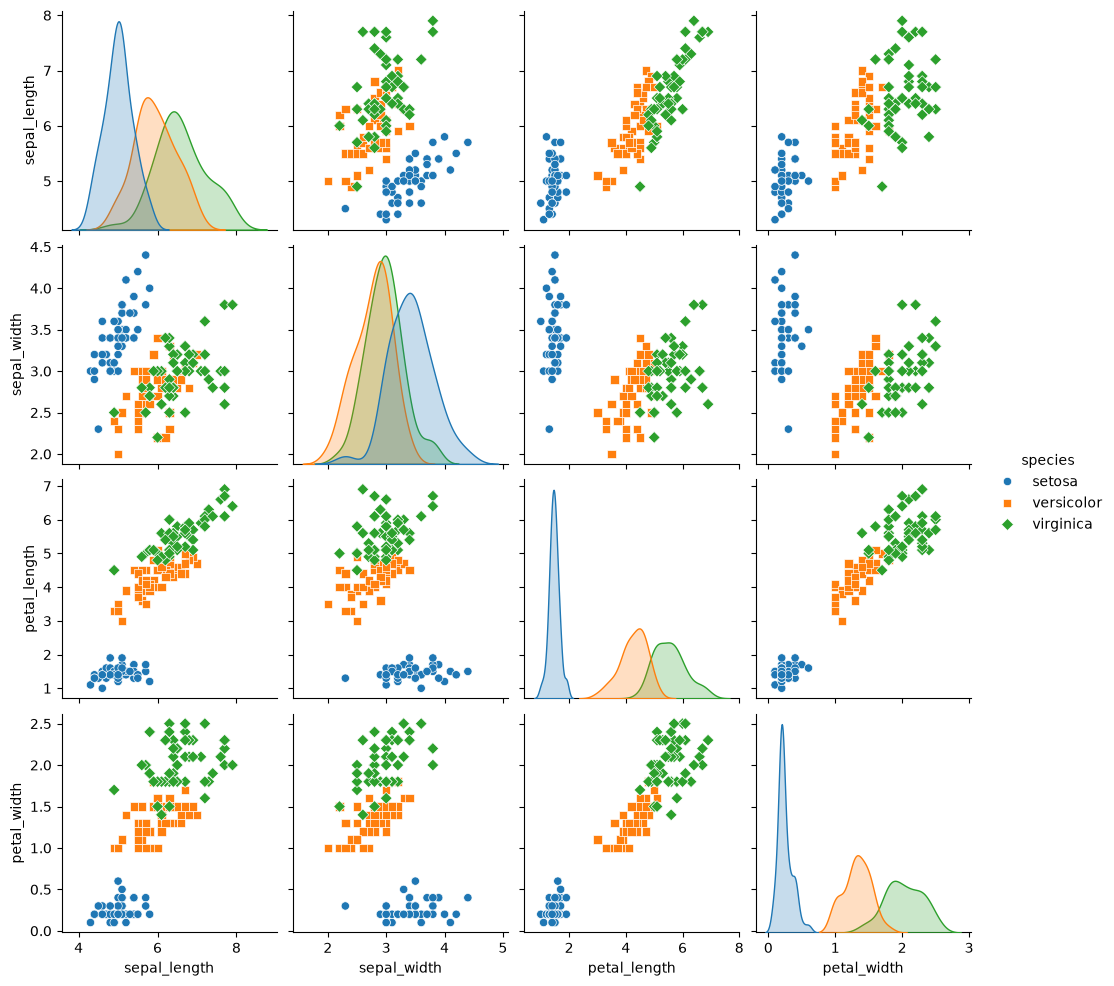

In [45]:
#3.3. Vẽ pairplot
sns.pairplot(df, hue='species', markers=["o", "s", "D"])

plt.show()

3.3. Dựa vào biểu đồ trên, ta có các nhận xét sau:
- Gần như với mọi trường hợp, dữ liệu cho giống 'setosa' luôn tập trung thành 1 cụm, tách biệt hoàn toàn so với 2 loài còn lại. Điều này làm nổi bật trong việc phân loại giống này. 
- Với 2 giống 'versicolor' và 'verginica' tuy có hình thành cụm trong 1 số biểu đồ nhưng 2 loài này có sự phân phối xếp chồng lên nhau khá nhiều, đặc biệt là các trục liên quan tới 'sepal_length' và 'sepal_width'. Tuy vậy, 2 loài này có sự phân biệt khá rõ ràng nếu ta xét các trục liên quan tới cánh hoa (petal)

In [ ]:
#Phần 4: Xác suất & Định lý Bayes
#4.1. Tính xác suất hậu nghiệm
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = (P_pos_givenB * P_B) + (P_pos_givenNB * (1 - P_B))
P_B_given_pos = (P_pos_givenB * P_B) / P_pos
print(round(P_B_given_pos,4))

0.1667


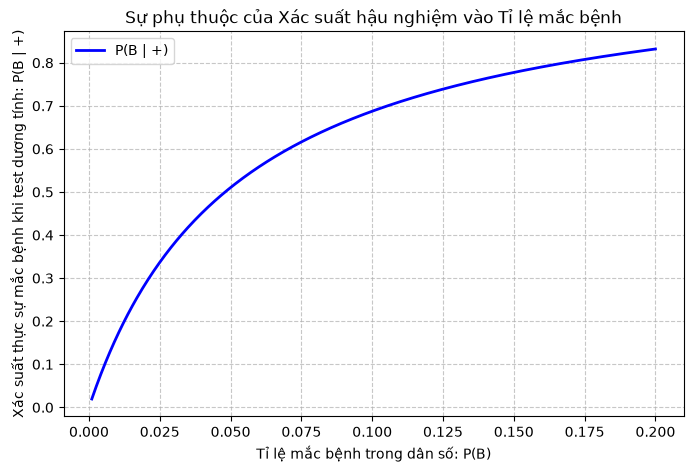

In [11]:
P_b = np.linspace(0.001, 0.2, 500)
Ppos_givenB = 0.99
Ppos_givenNB = 0.05

P_Nb = 1 - P_b

Ppos = (Ppos_givenB * P_b) + (Ppos_givenNB * P_Nb)

P_B_givenpos = (Ppos_givenB * P_b) / Ppos

plt.figure(figsize=(8, 5))
plt.plot(P_b, P_B_givenpos, label='P(B | +)', color='blue', linewidth=2)
plt.title('Sự phụ thuộc của Xác suất hậu nghiệm vào Tỉ lệ mắc bệnh')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số: P(B)')
plt.ylabel('Xác suất thực sự mắc bệnh khi test dương tính: P(B | +)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

4.2. Sau khi sử dụng định lý Bayes, trong trường hợp căn bệnh trở nên hiếm, ta thấy kết quả khá thấp trong khả năng người đó mắc bệnh khi kết quả xét nghiệm là dương tính. Điều này cho thấy việc dương tính giả lại cao hơn hẳn so với người bị dương tính thật và có hơi phản trực giác ban đầu, nhưng có thể giải thích rằng đó là vì số lượng người mắc bệnh quá thấp, trong khi những người khỏe mạnh hoặc không có bệnh lại cực kỳ lớn, nên việc sau khi xét nghiệm ra dương tính và người đó thật sự mắc bệnh không thật sự cao. Đặc biệt là khi căn bệnh càng hiếm thì số lượng người không mắc bệnh (nhưng kết quả ra dương tính) càng cao và áp đảo hơn hẳn số người thật sự mắc bệnh.